In [1]:
# Libraries:
import pymysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cryptography
from datetime import datetime
import scipy
from sqlalchemy import text, inspect, create_engine
from sqlalchemy.orm import sessionmaker

print("OK")

OK


### Level 1

1. Connect Python with MySQL Workbench and load the data from your Sprint 4 database to use it in all the exercises.

In [2]:
# Connection to MySQL (with SQLAlchemy)
USER = "root"                       
PASSWORD = "1234"                   
HOST = "localhost"                  
DB = "tienda_flor"                  

engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DB}")

Session = sessionmaker(bind=engine)

session = Session()

print("Engine and Session started.")

Engine and Session started.


2. For each item, create an appropriate visualization based on the specified variables. Interpret the results according to your data.
Remember: when selecting columns, always **think about the method you will use** and include those necessary for the visualization function you want to apply.

- One numerical variable.
- Two numerical variables.
- One categorical variable.
- One categorical variable and one numerical variable.
- Two categorical variables.
- Three variables combined.
- Create a Pairplot.

In [3]:
# To see the tables in my db (with inspect)
insp = inspect(engine)
table_names = insp.get_table_names()

print("Tables in database:", table_names)

Tables in database: ['american_users', 'card_status', 'companies', 'credit_cards', 'european_users', 'products', 'transactions', 'users']


In [10]:
# I read the tables I'd like to use in visuals and store them into variables (one by one)
transactions = pd.read_sql("SELECT * FROM transactions", engine)
companies = pd.read_sql("SELECT * FROM companies", engine)
products = pd.read_sql("SELECT * FROM products", engine)
transactions_products = pd.read_sql("SELECT * FROM transactions_products", engine)
users = pd.read_sql("SELECT * FROM users", engine)

In [5]:
# Check for nulls
#transactions.isna().sum()
#companies.isna().sum()
# products.isna().sum()
users.isna().sum()

id             0
name           0
surname        0
phone          0
email          0
birth_date     0
country        0
city           0
postal_code    0
address        0
region         0
dtype: int64

In [6]:
# Check for duplicates
# duplicate_rows = transactions.duplicated().sum()
# print(f"Number of completely duplicate rows: {duplicate_rows}")
# duplicate_rows = companies.duplicated().sum()
# print(f"Number of completely duplicate rows: {duplicate_rows}")
# duplicate_rows = products.duplicated().sum()
# print(f"Number of completely duplicate rows: {duplicate_rows}")
duplicate_rows = users.duplicated().sum()
print(f"Number of completely duplicate rows: {duplicate_rows}")

Number of completely duplicate rows: 0


- One numerical value

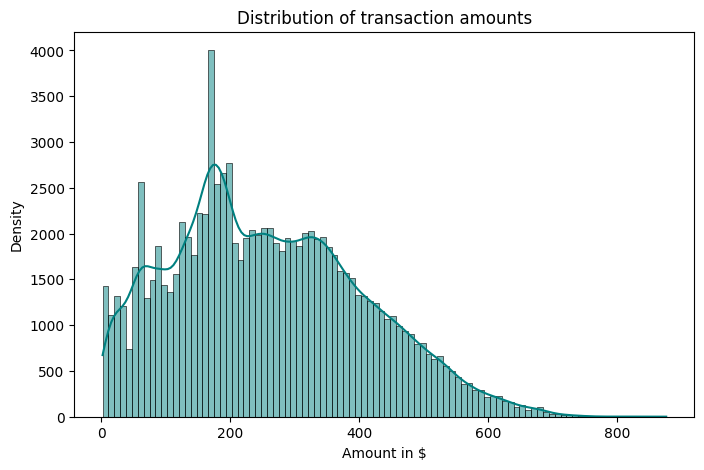

In [7]:
# Create a figure with specified size (width=8 inches, height=5 inches)
plt.figure(figsize=(8, 5))
sns.histplot(data=transactions, x='amount', kde=True, color='teal')

# Tags and title
plt.xlabel('Amount in $')
plt.ylabel('Density')
plt.title('Distribution of transaction amounts')
plt.show()

- Two numerical values

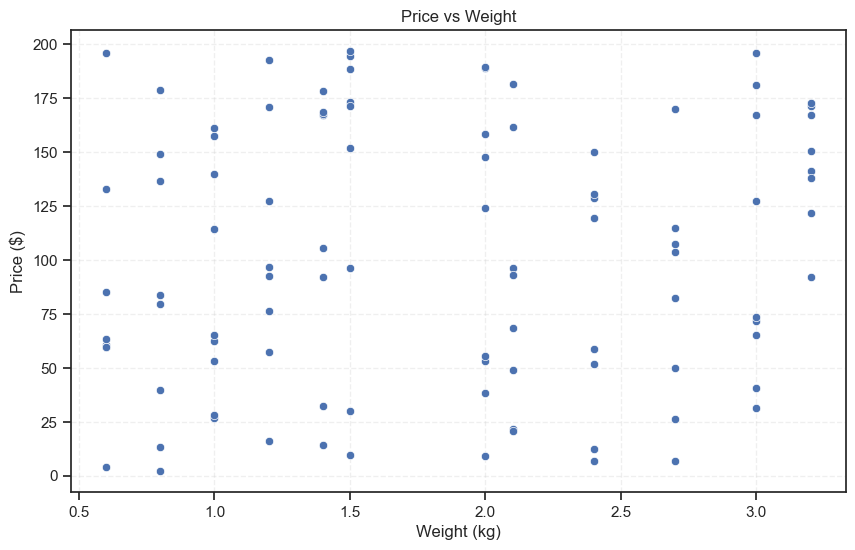

In [43]:
# Comparing products price and weight to see whether they're correlated or not
# products.dtypes
# products['price'] = products['price'].str.replace('$', '').astype(float)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=products, x='weight', y='price')
plt.xlabel('Weight (kg)')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3, linestyle='--')
plt.title('Price vs Weight')
plt.show()

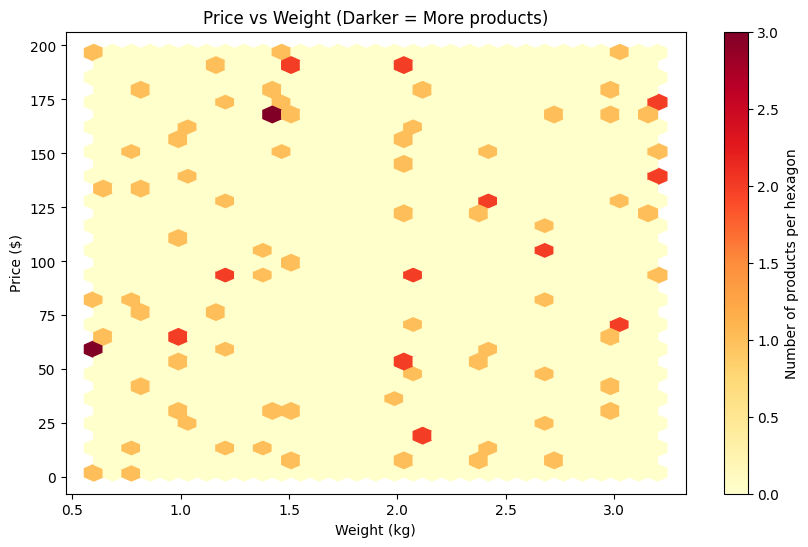

In [36]:
# ALTERNATIVE OPTION: Hexbin plot (if scatterplot points overlap too much to see patterns)

plt.figure(figsize=(10, 6))
hb = plt.hexbin(x=products['weight'], y=products['price'],       
    gridsize=30,               # Number of hexagons
    cmap='YlOrRd',             # Color map (lighter = fewer points, darker = more points)
)
plt.xlabel('Weight (kg)')
plt.ylabel('Price ($)')
plt.title('Price vs Weight (Darker = More products)')
plt.colorbar(hb, label='Number of products per hexagon')
plt.show()

- One categorical variable

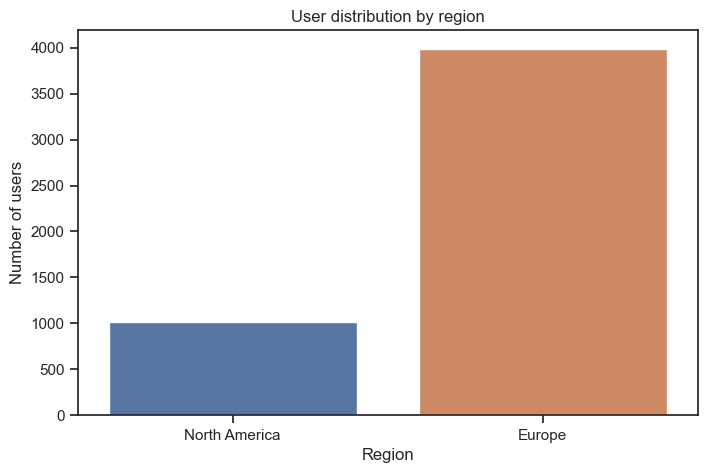

In [50]:
plt.figure(figsize=(8, 5))
sns.countplot(data=users, x='region', hue='region')

# Tags and title
plt.title('User distribution by region')
plt.xlabel('Region')
plt.ylabel('Number of users')
plt.show()

- One categorical and one numerical variable

In [ ]:
# One categorical and one numerical variable
# New df merging two tables (how='inner' is by default; then, not mandatory)
t_u = pd.merge(transactions, users[['id', 'birth_date', 'country','region']], left_on='user_id', right_on='id', how='inner')
t_u

,id_x,card_id,company_id,timestamp,amount,declined,product_ids,user_id,latitude,longitude,id_y,birth_date,country,region
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.199929,1.435540,4713,1996-01-28,France,Europe
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,"66, 69, 87",438,41.597206,12.221760,438,1957-08-16,Italy,Europe
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,"30, 11, 16, 81",2118,29.757296,-95.379637,2118,1995-09-04,United States,North America
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.60,0,72,2115,53.548884,-113.503053,2115,1969-02-19,Canada,North America
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,18,3025,52.208370,5.690806,3025,1961-02-08,Netherlands,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,CcS-5010,b-2234,2022-12-17 20:57:55,247.39,0,"20, 42, 54, 46",429,52.522274,13.404945,429,1965-05-20,Germany,Europe
99996,FFFB270D-F53A-4D5D-9666-E5307C53CC84,CcS-7655,b-2522,2024-05-13 03:42:03,349.13,0,"30, 87, 5, 66",3074,39.027118,-8.105230,3074,1988-12-24,Portugal,Europe
99997,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,2019-10-30 02:31:37,234.22,0,"16, 49",1008,59.332666,18.075323,1008,1957-11-13,Sweden,Europe
99998,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,2023-06-17 19:10:30,148.91,0,18,680,52.063504,4.308616,680,1969-12-18,Netherlands,Europe


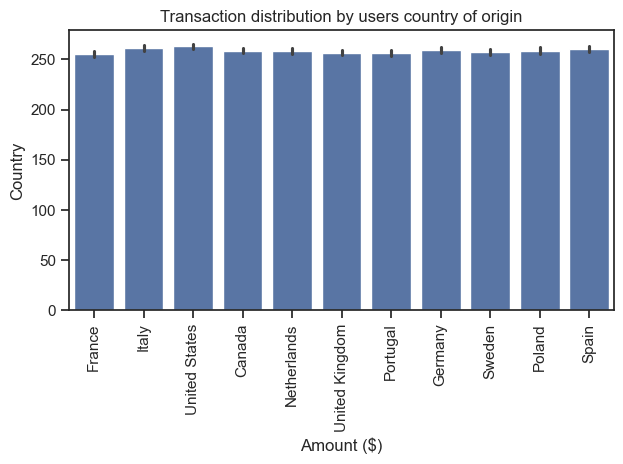

In [70]:
sns.barplot(data=t_u, x="country", y="amount")          # Change estimator: ..., estimator=np.median, errorbar=None)
# Shows average amount per country with error bars
plt.title('Transaction distribution by users country of origin')
plt.xlabel('Amount ($)')
plt.ylabel('Country')
plt.xticks(rotation=90)
plt.tight_layout()  # Adjust spacing to prevent labels from cutting off
plt.show()

- Two categorical variables

In [ ]:
#Dos variables Categoricas
# Heatmap 
plt.figure(figsize=(10, 6))
ct = pd.crosstab(df_last_transaction['country'], df_last_transaction['Status'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
#plt.title('Transacciones Aceptadas/Rechazadas por Origen del Usuario')
plt.show()

- Three variables combined

In [ ]:
# Third categorical variable
sns.catplot(
    data=tips, x="day", y="total_bill", hue="sex",          # hue (tercera variable para colorear, categórica)
    kind="violin", split=True,
)